In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded!")

All libraries loaded!


In [6]:
import os
print(os.getcwd())

C:\Users\kosur\anaconda3


In [8]:
df = pd.read_csv('train.csv')
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (891, 12)


In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:", df.columns.tolist())

Rows and Columns: (891, 12)

Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
df['Age'].fillna(df['Age'].median(), inplace=True)
print("Age missing values now:", df['Age'].isnull().sum())

Age missing values now: 0


C:\Users\kosur\AppData\Local\Temp\ipykernel_25852\3558041935.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [15]:
df = df.drop('Cabin', axis=1)
print("Cabin column removed!")

Cabin column removed!


In [16]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Embarked missing values now:", df['Embarked'].isnull().sum())

Embarked missing values now: 0


In [17]:
print("Final missing values check:")
print(df.isnull().sum())
print("\nCleaned dataset shape:", df.shape)

Final missing values check:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Cleaned dataset shape: (891, 11)


Overall Survival Rate: 38.38%


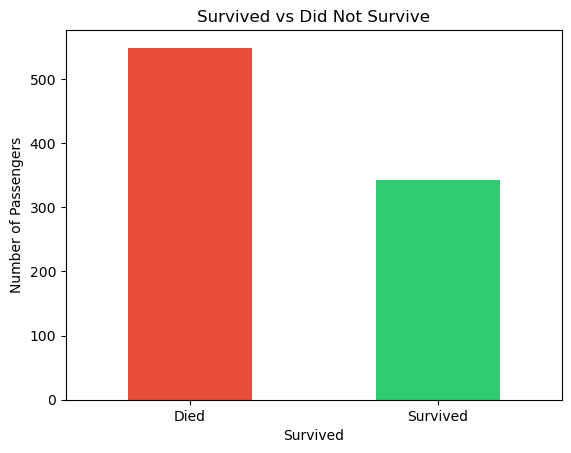

In [18]:
survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

df['Survived'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Survived vs Did Not Survive')
plt.xticks([0,1], ['Died','Survived'], rotation=0)
plt.ylabel('Number of Passengers')
plt.show()

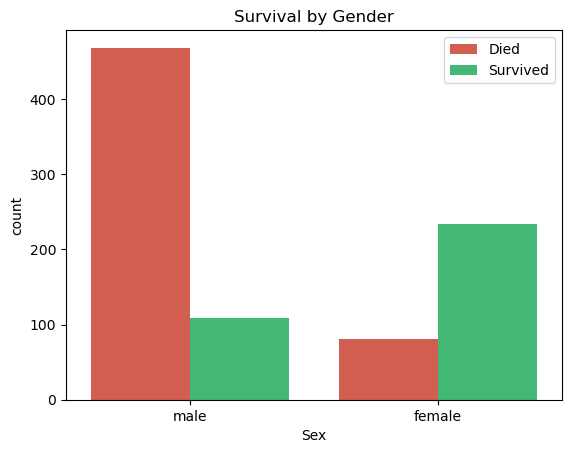

In [19]:
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#e74c3c','#2ecc71'])
plt.title('Survival by Gender')
plt.legend(['Died','Survived'])
plt.show()

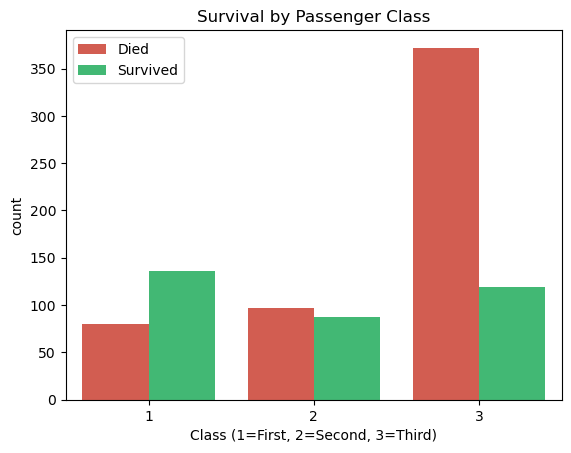

In [20]:
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['#e74c3c','#2ecc71'])
plt.title('Survival by Passenger Class')
plt.xlabel('Class (1=First, 2=Second, 3=Third)')
plt.legend(['Died','Survived'])
plt.show()

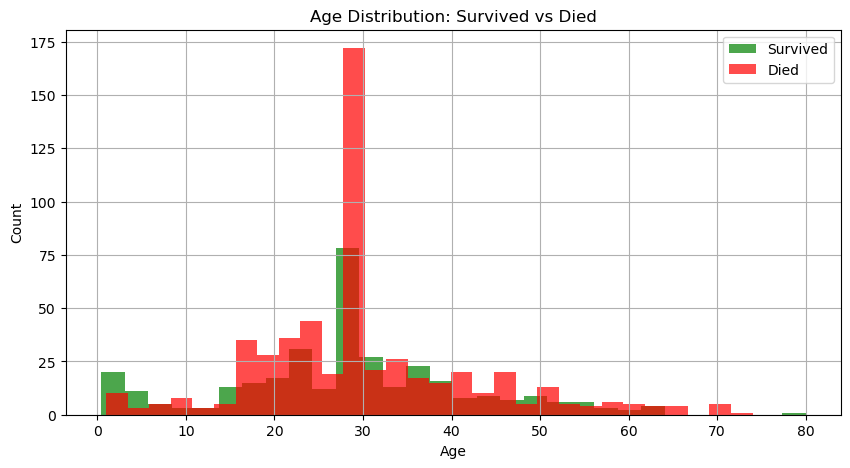

In [21]:
plt.figure(figsize=(10,5))
df[df['Survived']==1]['Age'].hist(alpha=0.7, label='Survived', color='green', bins=30)
df[df['Survived']==0]['Age'].hist(alpha=0.7, label='Died', color='red', bins=30)
plt.legend()
plt.title('Age Distribution: Survived vs Died')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

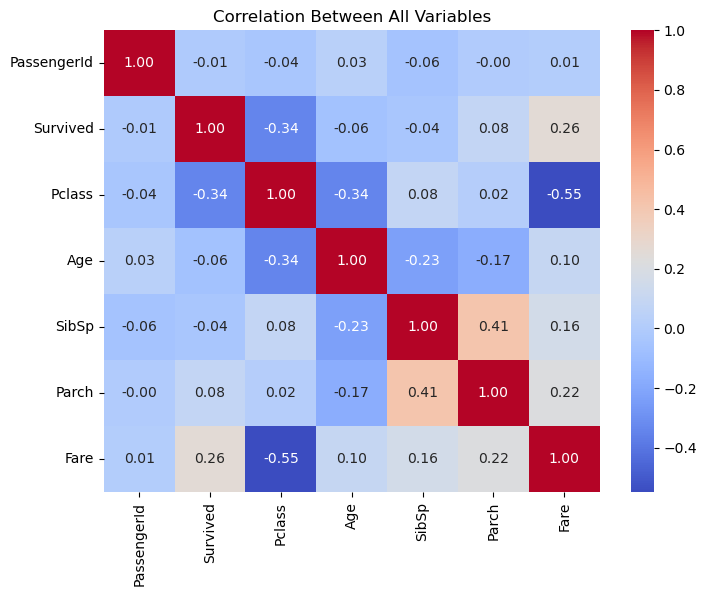

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between All Variables')
plt.show()

In [23]:
print("=" * 50)
print("KEY FINDINGS FROM TITANIC ANALYSIS")
print("=" * 50)
print(f"1. Overall survival rate: {df['Survived'].mean()*100:.1f}%")
print(f"2. Female survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"3. Male survival rate: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"4. 1st class survival rate: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"5. 3rd class survival rate: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"6. Average age of survivors: {df[df['Survived']==1]['Age'].mean():.1f} years")

KEY FINDINGS FROM TITANIC ANALYSIS
1. Overall survival rate: 38.4%
2. Female survival rate: 74.2%
3. Male survival rate: 18.9%
4. 1st class survival rate: 63.0%
5. 3rd class survival rate: 24.2%
6. Average age of survivors: 28.3 years
